In [1]:
from cProfile import label

import pandas  as pd
import matplotlib.pyplot as plt
import seaborn as sns
from traitlets.utils.descriptions import describe



In [2]:
df=pd.read_csv('data/Mall_Customers.csv')
df

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


In [3]:
df.info()
print(df.describe())

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Genre                   200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 7.9 KB
       CustomerID         Age  Annual Income (k$)  Spending Score (1-100)
count  200.000000  200.000000          200.000000              200.000000
mean   100.500000   38.850000           60.560000               50.200000
std     57.879185   13.969007           26.264721               25.823522
min      1.000000   18.000000           15.000000                1.000000
25%     50.750000   28.750000           41.500000               34.750000
50%    100.500000   36.000000           61.500000           

In [4]:
#male=0 , female=1
df['Genre']= df['Genre'].map({'Male':0, 'Female':1})

df

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,0,19,15,39
1,2,0,21,15,81
2,3,1,20,16,6
3,4,1,23,16,77
4,5,1,31,17,40
...,...,...,...,...,...
195,196,1,35,120,79
196,197,1,45,126,28
197,198,0,32,126,74
198,199,0,32,137,18


In [5]:
df.corr()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
CustomerID,1.000000,-0.057400,-0.026763,0.977548,0.013835
Genre,-0.057400,1.000000,-0.060867,-0.056410,0.058109
Age,-0.026763,-0.060867,1.000000,-0.012398,-0.327227
Annual Income (k$),0.977548,-0.056410,-0.012398,1.000000,0.009903
Spending Score (1-100),0.013835,0.058109,-0.327227,0.009903,1.000000


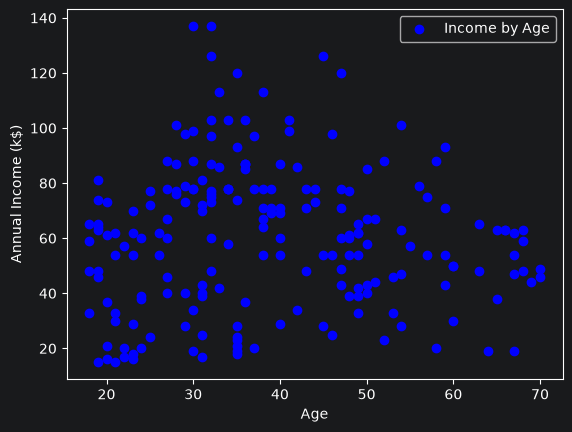

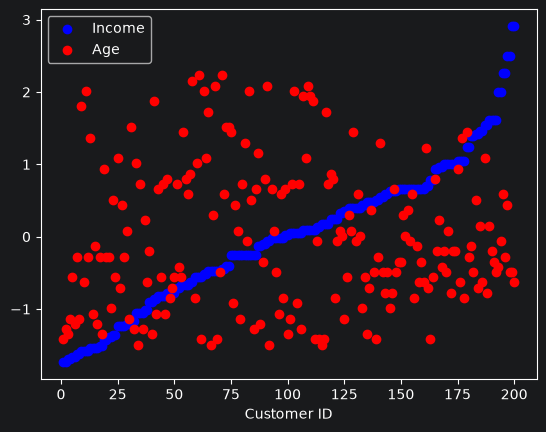

In [6]:
#Checking if there is any relation between Age and Annual Income.

plt.scatter(y=df['Annual Income (k$)'],x=df['Age'], label='Income by Age' ,color='Blue')
plt.legend()
plt.xlabel('Age')
plt.ylabel('Annual Income (k$)')
plt.show()
scaled_income=(df['Annual Income (k$)']-df['Annual Income (k$)'].mean())/df['Annual Income (k$)'].std()
scaled_Age=(df['Age']-df['Age'].mean())/df['Age'].std()

plt.scatter(x=df['CustomerID'],y=scaled_income,label='Income',color='blue')
plt.scatter(x=df['CustomerID'],y=scaled_Age,label='Age',color='Red')
plt.xlabel('Customer ID')
plt.legend()
plt.show()

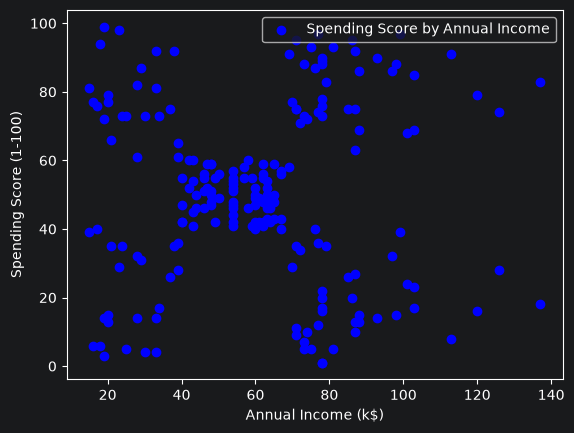

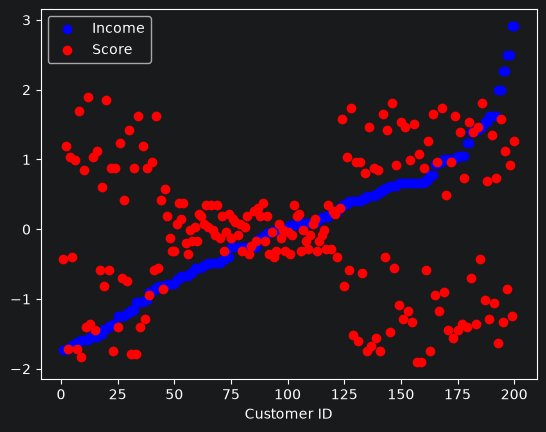

In [7]:
#Checking if there is any relation between Annual Income and Spending Score.

plt.scatter(x=df['Annual Income (k$)'],y=df['Spending Score (1-100)'], label='Spending Score by Annual Income' ,color='Blue')
plt.legend()
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.show()

scaled_Score=(df['Spending Score (1-100)']-df['Spending Score (1-100)'].mean())/df['Spending Score (1-100)'].std()

plt.scatter(x=df['CustomerID'],y=scaled_income,label='Income',color='blue')
plt.scatter(x=df['CustomerID'],y=scaled_Score ,label='Score',color='Red')
plt.xlabel('Customer ID')
plt.legend()
plt.show()


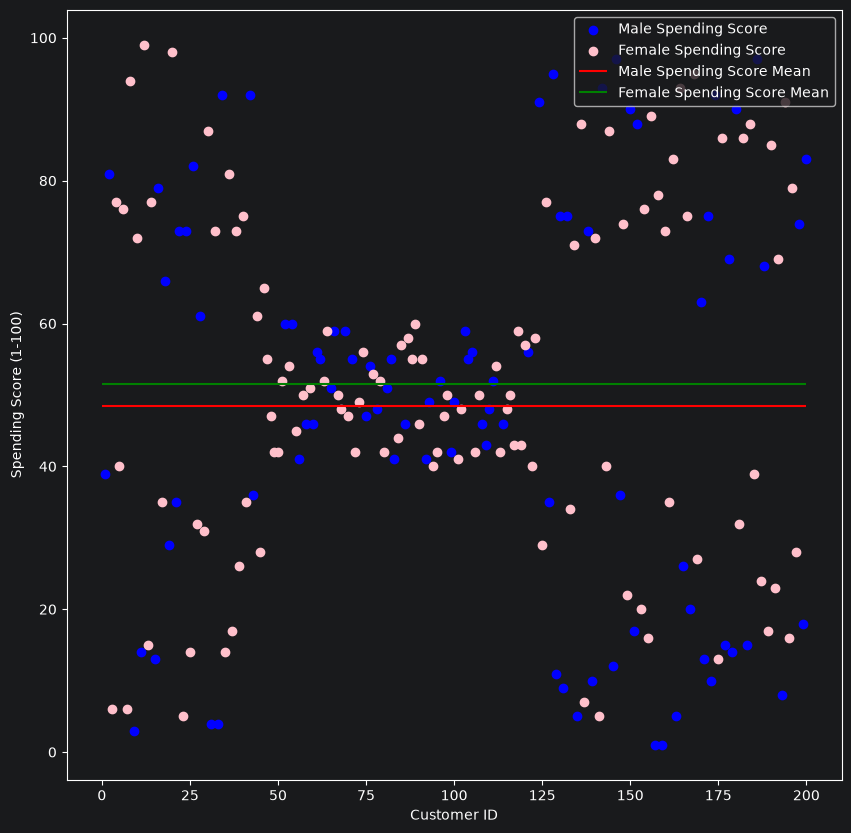

In [8]:
#Checking if there is any relation between Gender and Spending Score.

male_costumers=df[df['Genre']==0]
female_costumers=df[df['Genre']==1]

plt.figure(figsize=(10,10))
plt.scatter(x=male_costumers['CustomerID'], y=male_costumers['Spending Score (1-100)'], label='Male Spending Score',color='blue')
plt.scatter(x=female_costumers['CustomerID'], y=female_costumers['Spending Score (1-100)'], label='Female Spending Score',color='pink')
plt.hlines(xmin=0,xmax=200,y=male_costumers['Spending Score (1-100)'].mean(),color='red',label='Male Spending Score Mean')
plt.hlines(xmin=0,xmax=200,y=female_costumers['Spending Score (1-100)'].mean(),color='green',label='Female Spending Score Mean')
plt.xlabel('Customer ID')
plt.ylabel('Spending Score (1-100)')
plt.legend(loc='upper right')